In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##  Checking the Training and Validation or Test Data



In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define dataset paths
dataset_path = "/content/drive/MyDrive/PlantVillage"  # Change to your dataset path
output_base = "/content/drive/MyDrive/can_tomato"  # Where the split dataset will be stored

train_dir = os.path.join(output_base, "train")
test_dir = os.path.join(output_base, "test")

# Create train and test directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Get class names
classes = os.listdir(dataset_path)

# Split and copy images
split_ratio = 0.2  # 20% test, 80% train

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    # Ensure it's a valid directory
    if not os.path.isdir(class_path):
        print(f"Skipping {class_name} (Not a directory)")
        continue

    # Debug: Check if folder exists
    if not os.path.exists(class_path):
        print(f"Error: Folder {class_path} does not exist!")
        continue

    # Create class subdirectories in train and test folders
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    # List all images in class folder (case-insensitive filtering)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    # Debug: Print detected images
    print(f"Class: {class_name}, Found {len(images)} images")

    # Check if images list is empty
    if not images:
        print(f"⚠️ Warning: No images found in {class_path}. Skipping this class.")
        continue

    # Shuffle and split dataset
    train_images, test_images = train_test_split(images, test_size=split_ratio, random_state=42)

    # Copy images to train folder
    for img in train_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(train_dir, class_name, img)
        shutil.copy2(src, dst)

    # Copy images to test folder
    for img in test_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(test_dir, class_name, img)
        shutil.copy2(src, dst)

print("✅ Dataset split completed!")

Class: Tomato__Target_Spot, Found 1404 images
Class: Tomato__Tomato_mosaic_virus, Found 373 images
Class: Tomato__Tomato_YellowLeaf__Curl_Virus, Found 3208 images


Found 495 files belonging to 6 classes.
['Bacterial spot', 'Black mold', 'Gray spot', 'Late blight', 'health', 'powdery mildew']


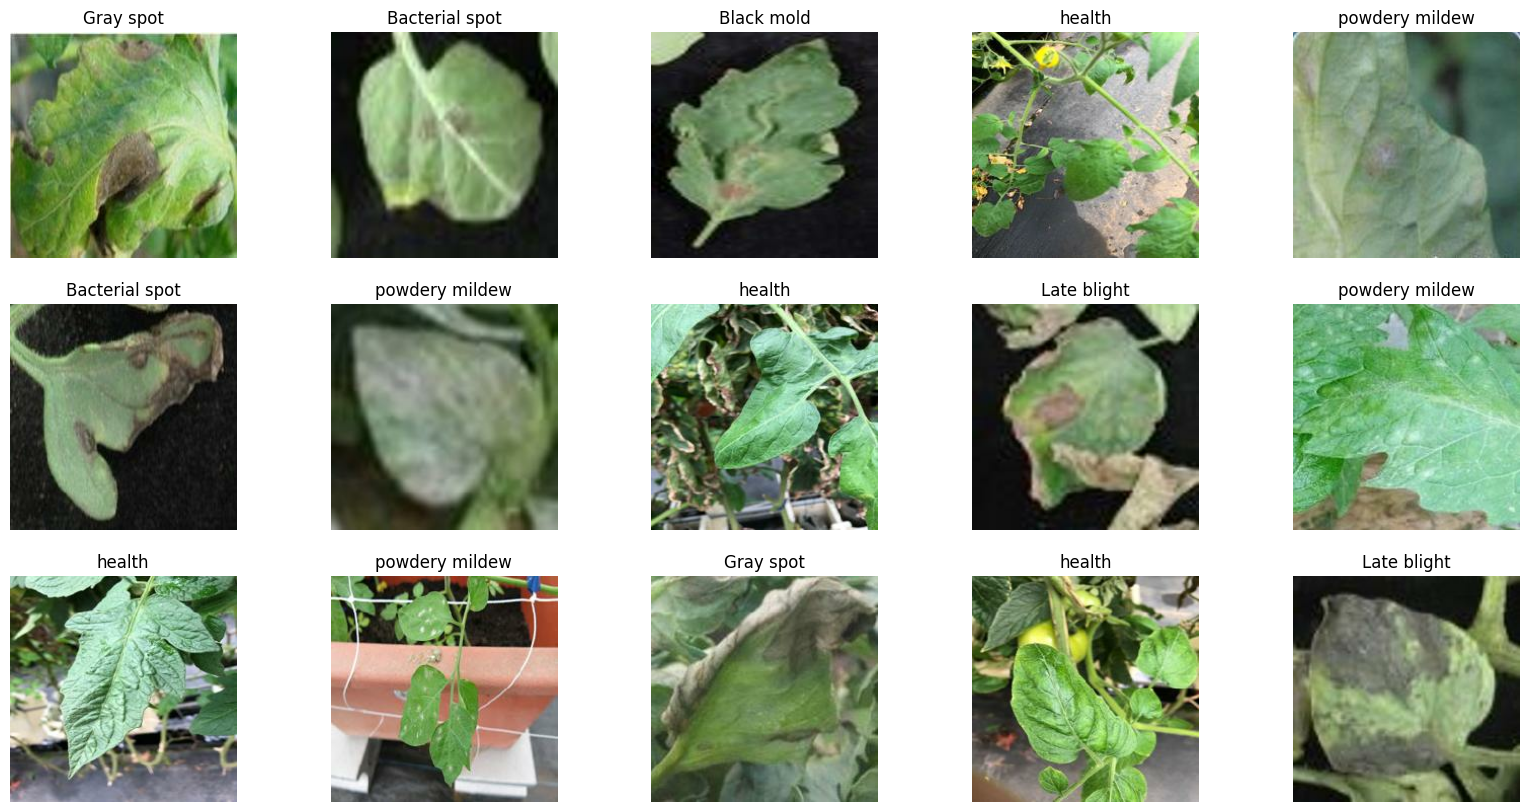

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.applications.inception_v3 import InceptionV3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# DATA VISUALIZATION
import tensorflow as tf

IMAZE_SIZE=[224,224]
IMAGE_SIZE=[224,224]
BATCH_SIZE=32
NUM_OF_CHANNELS=3
train_path="/content/drive/MyDrive/Colab Notebooks/taiwan/Preprocessed data/Train"
test_path="/content/drive/MyDrive/Colab Notebooks/taiwan/Preprocessed data/Test"

# Assuming you are using image_dataset_from_directory
dataset = tf.keras.utils.image_dataset_from_directory(
    directory=train_path, # Replace with your training data path
    labels='inferred',
    label_mode='int',
    image_size = IMAGE_SIZE,
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names = dataset.class_names
print(class_names)
plt.figure(figsize=(20, 10))
for image_batch, label_batch in dataset.take(1):
    for i in range(15):
        ax = plt.subplot(3, 5, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score

# Parameters
IMG_SIZE = (128, 128)  # Resize images to 128x128
BATCH_SIZE = 32
EPOCHS = 40  # Higher epochs with early stopping

# Dataset paths
train_dir = "/content/drive/MyDrive/Gain_fasr/train"
test_dir = "/content/drive/MyDrive/Gain_fasr/test"

# Automatically detect the number of classes
NUM_CLASSES = len(os.listdir(train_dir))
print(f"Detected {NUM_CLASSES} classes.")

# Data Augmentation for the Training Set
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Data Preprocessing for the Testing Set (No augmentation, only normalization)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

# Load Datasets
print("Loading training dataset...")
train_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'  # One-hot encoded labels
)

print("Loading testing dataset...")
test_dataset = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'  # One-hot encoded labels
)

# Build CNN Model
def build_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),  # Dropout to prevent overfitting
        Dense(num_classes, activation='softmax')  # Output layer for multi-class classification
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn()

# Early Stopping Callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Stop after 5 epochs with no improvement
    restore_best_weights=True  # Restore the best model weights
)

# Train the CNN Model
print("\nTraining CNN Model...")
history = cnn_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    callbacks=[early_stopping],  # Include early stopping
    verbose=1
)

# Evaluate on Test Data
print("\nEvaluating CNN Model...")
test_loss, test_accuracy = cnn_model.evaluate(test_dataset)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Make Predictions
predictions = cnn_model.predict(test_dataset)
y_pred = np.argmax(predictions, axis=1)
y_true = test_dataset.classes

# Classification Report
print("\nCNN Classifier Report:")
print(classification_report(y_true, y_pred, target_names=list(test_dataset.class_indices.keys())))



Detected 10 classes.
Loading training dataset...
Found 12804 images belonging to 10 classes.
Loading testing dataset...
Found 3207 images belonging to 10 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training CNN Model...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 133s 314ms/step - accuracy: 0.3138 - loss: 1.9135 - val_accuracy: 0.5949 - val_loss: 1.1416
Epoch 2/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 120s 299ms/step - accuracy: 0.6125 - loss: 1.1224 - val_accuracy: 0.6470 - val_loss: 1.0025
Epoch 3/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 141s 296ms/step - accuracy: 0.6979 - loss: 0.8622 - val_accuracy: 0.5887 - val_loss: 1.3599
Epoch 4/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 118s 294ms/step - accuracy: 0.7273 - loss: 0.7920 - val_accuracy: 0.6370 - val_loss: 1.1649
Epoch 5/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 119s 297ms/step - accuracy: 0.7643 - loss: 0.6803 - val_accuracy: 0.6798 - val_loss: 1.0435
Epoch 6/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 118s 294ms/step - accuracy: 0.7843 - loss: 0.6344 - val_accuracy: 0.7350 - val_loss: 0.8624
Epoch 7/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 119s 298ms/step - accuracy: 0.8067 - loss: 0.5417 - val_accuracy: 0.7683 - val_loss: 0.6854
Epoch 8/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 119s 297ms/step - accuracy: 0.8201 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━

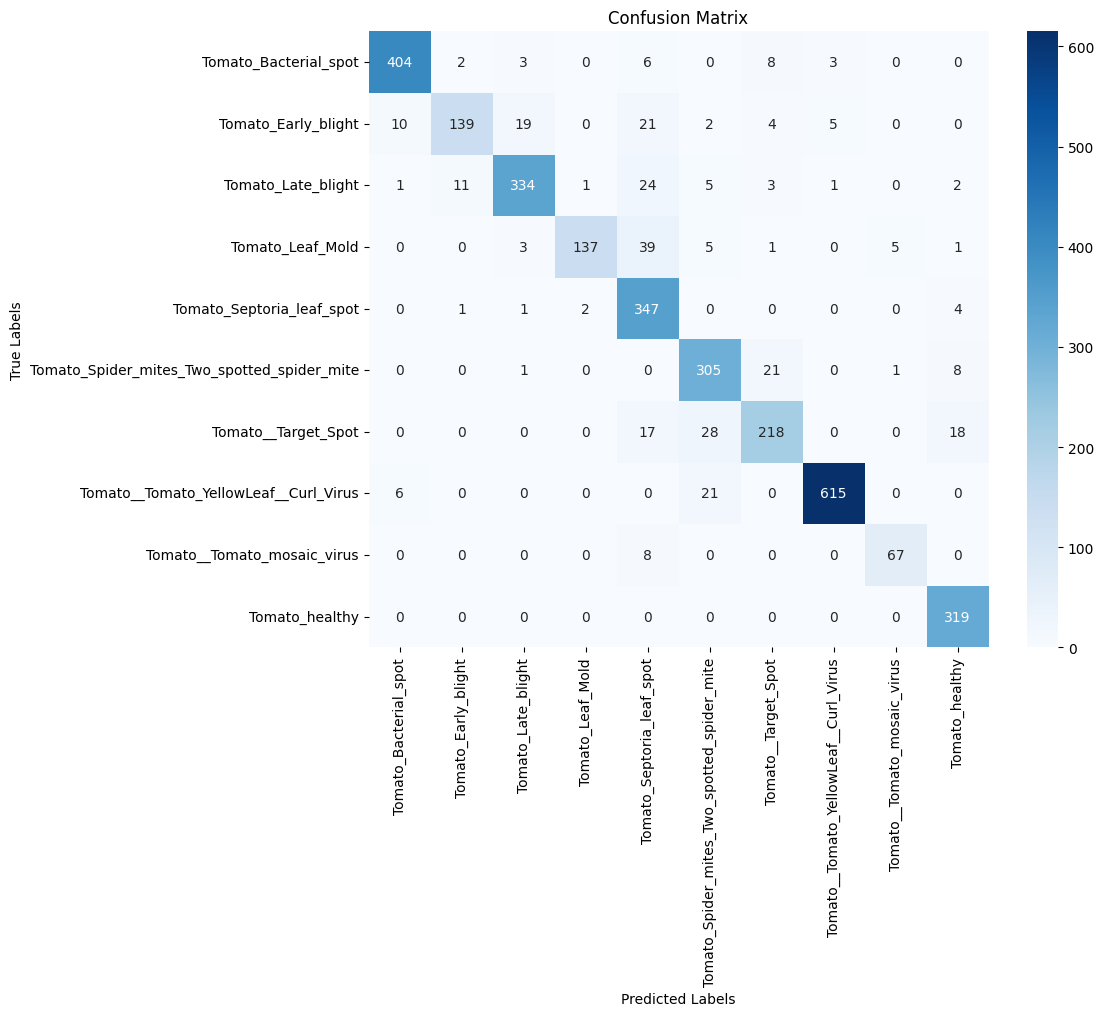

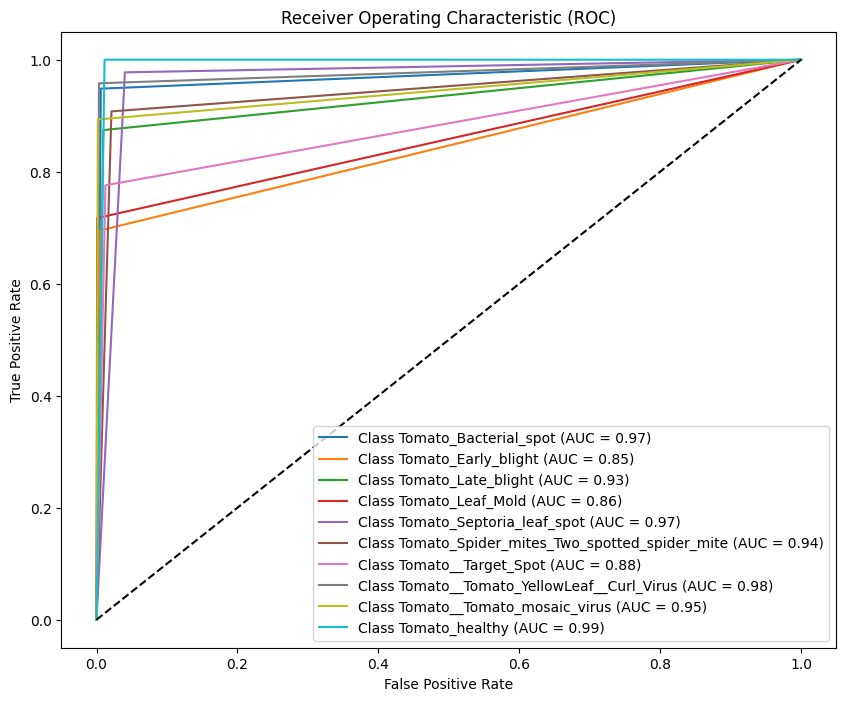

In [ ]:
!pip install scikit-learn
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Get the true labels and predictions for your test dataset
# Replace validation_generator with your test data generator if necessary
y_true = []
y_pred = []

test_dataset.reset()  # Reset the generator to start from the beginning

# Assuming your test data generator is validation_generator
for i in range(len(test_dataset)):
    x_batch, y_batch_true = test_dataset[i] # Changed validation_generator to test_dataset
    y_batch_pred = cnn_model.predict(x_batch) # Changed model to cnn_model
    y_true.extend(np.argmax(y_batch_true, axis=1))
    y_pred.extend(np.argmax(y_batch_pred, axis=1))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
# Assuming validation_generator is your test data generator
# and it has a property called `class_indices`
class_names = list(test_dataset.class_indices.keys()) # Changed validation_generator to test_dataset
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


# ROC Curve
NUM_CLASSES = len(class_names)  # Number of classes
plt.figure(figsize=(10, 8))
# Use y_true and y_pred calculated earlier
# Convert y_true to one-hot encoding for ROC curve calculation
y_true_onehot = tf.keras.utils.to_categorical(y_true, NUM_CLASSES)
y_pred_onehot = tf.keras.utils.to_categorical(y_pred, NUM_CLASSES)

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_onehot[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()